Kelly Criterion

#from Wiki <br />
In probability theory, the Kelly criterion (or Kelly strategy or Kelly bet) is a formula for sizing a sequence of bets by maximizing the long-term expected value of the logarithm of wealth, which is equivalent to maximizing the long-term expected geometric growth rate. John Larry Kelly Jr., a researcher at Bell Labs, described the criterion in 1956.

The practical use of the formula has been demonstrated for gambling, and the same idea was used to explain diversification in investment management. In the 2000s, Kelly-style analysis became a part of mainstream investment theory and the claim has been made that well-known successful investors including Warren Buffett and Bill Gross use Kelly methods. Also see intertemporal portfolio choice. It is also the standard replacement of statistical power in anytime-valid statistical tests and confidence intervals, based on e-values and e-processes.

$$
f^*=p- \frac{q}{b} =p-\frac{1-p}{b}
$$

where

$f^*$ is the fraction of the current bankroll to wager. <br />
$p$ is the probability to win. <br />
$q$ is the probability to loss. <br />
$b$ is the proportion of the bet gained with a win. <br />




probability of win and b in Trading. <br />

| Word (symbol) | Definition | Notes |
|----------------|------------|-------|
| **Probability to win (p)** | P(win) | Example: If you trade 100 times and 30 of those trades are profitable while 70 result in losses, the probability to win is 30%.<br>Normally, win probability is expressed in percentage terms, but when using `p`, the percentage is not used.<br>If the win probability is 30%, then p = 0.3. |
| **Probability to lose (q)** | P(loss) | When expressed with `q`, the percentage is not used. If the probability to lose is 70%, then q = 0.7.<br>p+q=1. |
| **Risk/Reward ratio (b)** | Average Win/Average Loss | Example: A risk/reward ratio of 3 means that if the average loss from losing trades is 1, the average profit from winning trades is 3. |


Examples of kelly ratio

| Win Rate, Risk/Reward Ratio | System TPI | Kelly Criterion f Value | Meaning |
|-----------------------------|------------|-------------------------|---------|
| 50%, 1 | 1 | 0 | Invest less than or equal to 0% of the capital. In other words, do not trade. |
| 50%, 2 | 1.5 | 0.25 | For each trade, invest less than or equal to 25% of the capital. |
| 30%, 4 | 1.5 | 0.125 | For each trade, invest less than or equal to 12.5% of the capital. |


### Trading Guide

- When applying the Kelly criterion to determine the trade size, it is only meaningful if the win rate and risk/reward ratio of the trading method are consistent.
- You must apply the win rate and risk/reward ratio based on at least 100 trades of meaningful trading data.
- As market conditions and situations change, continuously calculate and apply the updated win rate and risk/reward ratio.
- If your actual results differ significantly from the calculated win rate and risk/reward ratio, or if your account balance suffers a significant drawdown, stop trading immediately and thoroughly review your trading method to check if any serious errors were overlooked. If you find such errors, refrain from trading until the method is improved.

### Risks of Capital Overbetting

- The Kelly criterion warns against overbetting, which increases the risk of ruin.
- In reality, many traders have experienced ruin due to overbetting.
- Overbetting even in just a few trades can lead to significant losses and ruin, and is not a part of proper trading discipline.
- Regardless of whether your trading method has a high win rate or a new edge, repeated overbetting will inevitably lead to ruin.

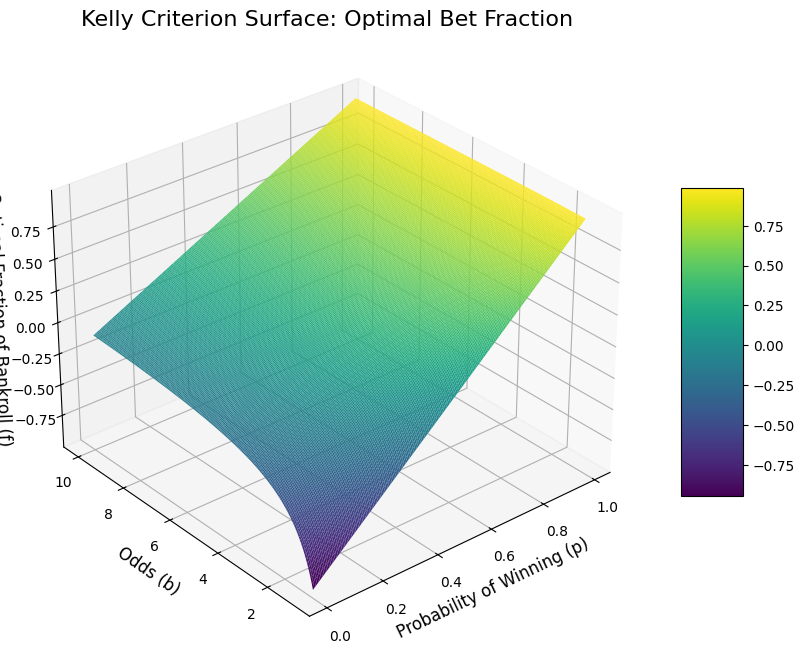

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define the function f(p, b) = p - (1 - p) / b
def kelly_fraction(p, b):
    return p - (1 - p) / b

# Generate a higher resolution for p (probability) and b (odds)
p_values = np.linspace(0.01, 0.99, 200)  # Probability of winning
b_values = np.linspace(1.01, 10, 200)    # Odds

# Create a meshgrid with finer resolution
P, B = np.meshgrid(p_values, b_values)

# Calculate the Kelly fraction for each combination of p and b
F = kelly_fraction(P, B)

# Plotting the 3D surface with higher detail
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Enhanced Surface plot
surface = ax.plot_surface(P, B, F, cmap='viridis', edgecolor='none', rstride=1, cstride=1, antialiased=True)

# Labels and title
ax.set_title('Kelly Criterion Surface: Optimal Bet Fraction', fontsize=16)
ax.set_xlabel('Probability of Winning (p)', fontsize=12)
ax.set_ylabel('Odds (b)', fontsize=12)
ax.set_zlabel('Optimal Fraction of Bankroll (f)', fontsize=12)

# Adjust the viewing angle for better visibility
ax.view_init(elev=30, azim=230)

# Add a color bar for reference
fig.colorbar(surface, shrink=0.5, aspect=5)

# Adjust the tick sizes for better readability
ax.tick_params(axis='both', which='major', labelsize=10)

plt.show()

Winning Probability (p): 0.5199
Losing Probability (q): 0.4801
Kelly Betting Size (f*): 0.0767


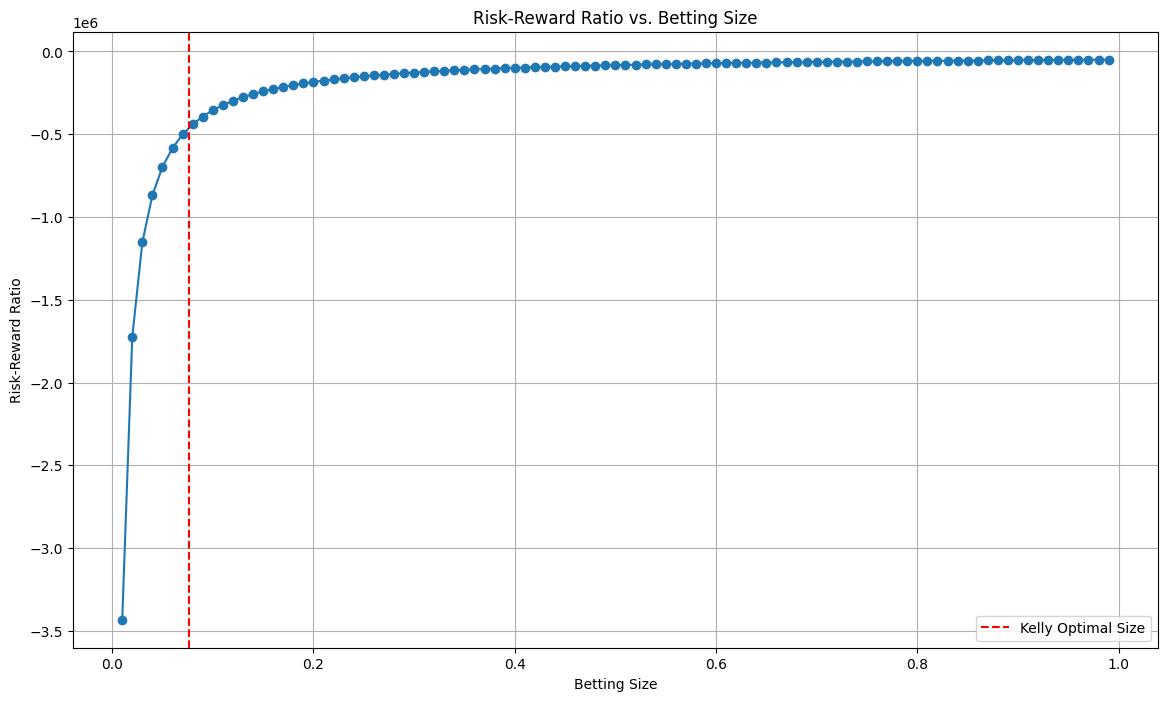

In [2]:


import numpy as np
from scipy.stats import norm
import pandas as pd
import matplotlib.pyplot as plt

# Given parameters
mean_return = 0.001  # Assumed mean daily return
volatility = 0.02  # Assumed daily volatility
n_simulations = 1000  # Number of simulations
n_days = 252  # Number of trading days (1 year)
# Simulate returns
simulated_returns = np.random.normal(mean_return, volatility, (n_simulations, n_days))


# Calculate loss probability q
q = norm.cdf(0, loc=mean_return, scale=volatility)

# Winning probability p
p = 1 - q

# Kelly Criterion optimal betting size
f_star = (p - q) / (1 - q)  # For even odds

# Display the probabilities and Kelly betting size
print(f"Winning Probability (p): {p:.4f}")
print(f"Losing Probability (q): {q:.4f}")
print(f"Kelly Betting Size (f*): {f_star:.4f}")

# Simulation parameters
np.random.seed(42)
n_simulations = 1000  # Number of simulations
n_days = 252  # Number of trading days (1 year)
initial_investment = 10000  # Initial investment amount
betting_sizes = np.arange(0.01, 1, 0.01)  # Betting sizes from 0.1 to 2 (10% to 200%)

# Function to calculate maximum drawdown
def max_drawdown(returns):
    cumulative = np.cumprod(1 + returns)
    drawdowns = cumulative / np.maximum.accumulate(cumulative) - 1
    return drawdowns.min()

# Results storage
mean_returns = []
variance_returns = []
max_drawdowns = []
risk_reward_ratios = []

# Loop through each betting size
for bet_size in betting_sizes:
    final_values = []
    cumulative_returns = []

    for sim in range(n_simulations):
        investment = initial_investment
        daily_returns = []

        for day in range(n_days):
            daily_return = simulated_returns[sim, day] * bet_size
            daily_returns.append(daily_return)
            investment *= (1 + daily_return)

        cumulative_returns.append(daily_returns)
        final_values.append(investment)

    cumulative_returns = np.array(cumulative_returns)
    mean_return = np.mean(final_values)
    variance_return = np.var(cumulative_returns[:, -1])
    max_dd = np.mean([max_drawdown(returns) for returns in cumulative_returns])
    risk_reward_ratio = mean_return / (max_dd if max_dd != 0 else 1)

    mean_returns.append(mean_return)
    variance_returns.append(variance_return)
    max_drawdowns.append(max_dd)
    risk_reward_ratios.append(risk_reward_ratio)

# Convert results to DataFrame for analysis
results_df = pd.DataFrame({
    'Betting Size': betting_sizes,
    'Mean Return': mean_returns,
    'Variance of Return': variance_returns,
    'Max Drawdown': max_drawdowns,
    'Risk-Reward Ratio': risk_reward_ratios
})

# Plot Risk-Reward Ratio vs. Betting Size
plt.figure(figsize=(14, 8))
plt.plot(results_df['Betting Size'], results_df['Risk-Reward Ratio'], marker='o')
plt.axvline(x=f_star, color='r', linestyle='--', label='Kelly Optimal Size')
plt.xlabel('Betting Size')
plt.ylabel('Risk-Reward Ratio')
plt.title('Risk-Reward Ratio vs. Betting Size')
plt.legend()
plt.grid(True)
plt.show()